## Customer Churn Prediction System


### Problem statement

Telecom companies lose customers because of churn.
The goal of this project is to predict whether a customer will leave the telecom company based on customer details, subscription plans, and billing information.

In [42]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid', palette='Set2')

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [45]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [46]:
import joblib
import pickle

print("✅  All libraries imported successfully!")

✅  All libraries imported successfully!


In [47]:
df=pd.read_csv("/home/user/Desktop/ML_PROJECTS/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [48]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [49]:
print(df.tail())

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
7038              Yes         Yes         Yes  

In [50]:
print(df.shape)

(7043, 21)


In [51]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [53]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [54]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [55]:
print(df.duplicated().sum())

0


In [56]:
print("Categorical columns unique-value counts:")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col:25s}: {df[col].nunique()} unique → {df[col].unique()[:5]}")

Categorical columns unique-value counts:
  customerID               : 7043 unique → ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
  gender                   : 2 unique → ['Female' 'Male']
  Partner                  : 2 unique → ['Yes' 'No']
  Dependents               : 2 unique → ['No' 'Yes']
  PhoneService             : 2 unique → ['No' 'Yes']
  MultipleLines            : 3 unique → ['No phone service' 'No' 'Yes']
  InternetService          : 3 unique → ['DSL' 'Fiber optic' 'No']
  OnlineSecurity           : 3 unique → ['No' 'Yes' 'No internet service']
  OnlineBackup             : 3 unique → ['Yes' 'No' 'No internet service']
  DeviceProtection         : 3 unique → ['No' 'Yes' 'No internet service']
  TechSupport              : 3 unique → ['No' 'Yes' 'No internet service']
  StreamingTV              : 3 unique → ['No' 'Yes' 'No internet service']
  StreamingMovies          : 3 unique → ['No' 'Yes' 'No internet service']
  Contract                 : 3 unique → ['M

## Data Preprocessing

In [57]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

Steps:
1. Remove `customerID` (unique identifier — no predictive power)
2. Convert `TotalCharges` from string → numeric (some rows contain whitespace)
3. Handle the tiny number of resulting NaN rows
4. Encode the binary target `Churn` (Yes → 1, No → 0)
5. Label-encode remaining binary categoricals; One-Hot-Encode multi-class ones
6. Scale numeric features with `StandardScaler`

In [58]:
# step 1--drop customerId
df.drop(columns=['customerID'],inplace=True)
print("customer id dropped and new shape is",df.shape)

customer id dropped and new shape is (7043, 20)


In [59]:
# step 2---Fix TotalCharges Datatypes
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaNs after conversion: {df['TotalCharges'].isnull().sum()}")

TotalCharges NaNs after conversion: 11


In [60]:
# step 3--Impute the tiny number of NaN rows 
# Strategy: fill with median (robust to outliers)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


/tmp/ipykernel_7563/4182422581.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [61]:
# step 4-- Encode Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts:\n", df['Churn'].value_counts())

Churn value counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [62]:
# step 5--Identify column types
binary_cols   = []   # exactly 2 unique values  → LabelEncoder
multicat_cols = []   # 3+ unique values          → OneHotEncoder

for col in df.select_dtypes(include='object').columns:
    n = df[col].nunique()
    if n == 2:
        binary_cols.append(col)
    else:
        multicat_cols.append(col)

print("Binary categorical  :", binary_cols)
print("Multi-class categorical:", multicat_cols)

Binary categorical  : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class categorical: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [63]:
#Step 5a · Label-encode binary categoricals 
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Binary columns encoded ✔")

Binary columns encoded ✔


In [64]:
# Step 5b · One-Hot-Encode multi-class categoricals 
df = pd.get_dummies(df, columns=multicat_cols, drop_first=True)
print(f"Shape after One-Hot Encoding: {df.shape}")
df.head(2)


Shape after One-Hot Encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True


In [65]:
#step 6--Target and split
from sklearn.preprocessing import LabelEncoder, StandardScaler
X = df.drop(columns=['Churn'])
y = df['Churn']

# ── Step 6b · Scale numeric features ─────────────────────────────
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)
print("\nScaled numeric preview:")
X[numeric_cols].describe().round(3)

Feature matrix shape : (7043, 30)
Target vector shape  : (7043,)

Scaled numeric preview:


,tenure,MonthlyCharges,TotalCharges
count,7043.000,7043.000,7043.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.318,-1.546,-0.999
25%,-0.952,-0.973,-0.830
50%,-0.137,0.186,-0.390
75%,0.921,0.834,0.664
max,1.614,1.794,2.827


## Exploratiry DataAnalysis

/tmp/ipykernel_7563/3963458232.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[1], palette=['#66b3ff', '#ff9999'])
/tmp/ipykernel_7563/3963458232.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])


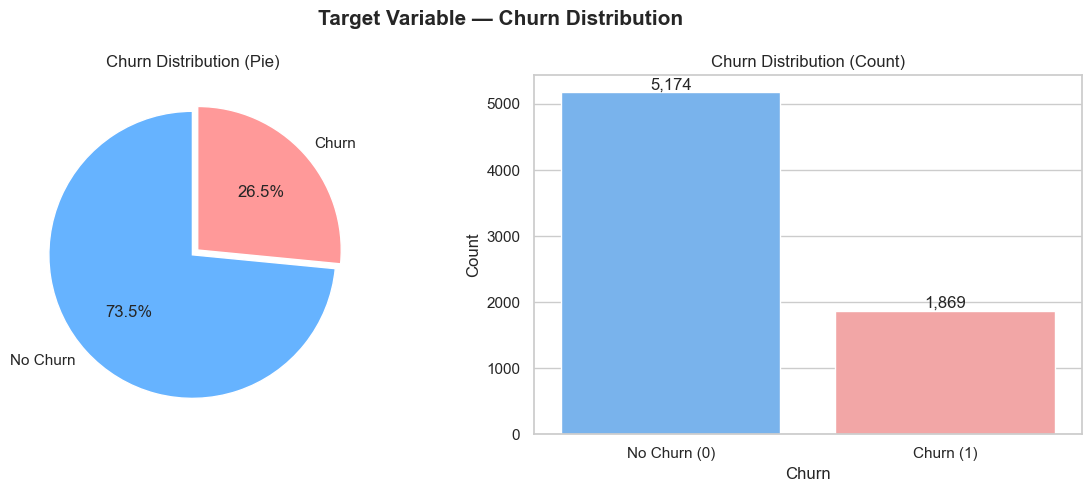


🔍 Insight: Dataset is imbalanced (~73% No Churn, ~27% Churn).
   This is a common real-world scenario. F1-Score & Recall are key metrics.


In [66]:
#  Churn distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = y.value_counts()
axes[0].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999'],
    explode=(0, 0.05)
)
axes[0].set_title('Churn Distribution (Pie)')

sns.countplot(x=y, ax=axes[1], palette=['#66b3ff', '#ff9999'])
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[1].set_title('Churn Distribution (Count)')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

plt.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Insight: Dataset is imbalanced (~73% No Churn, ~27% Churn).")
print("   This is a common real-world scenario. F1-Score & Recall are key metrics.")

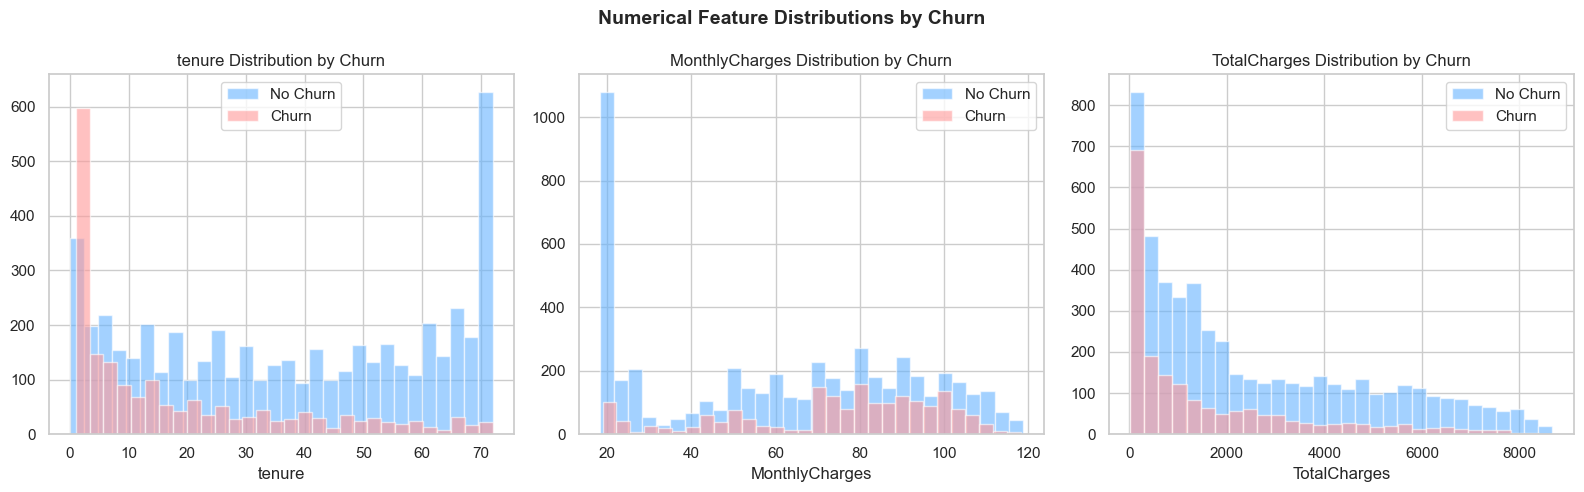


🔍 Insights:
  • Short-tenure customers churn more — they haven't built loyalty yet.
  • Higher monthly charges correlate with higher churn risk.
  • Customers with low total charges (newer customers) tend to churn more.


In [67]:
# Numerical feature distributions 
raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')   # use original for visuals
raw['TotalCharges'] = pd.to_numeric(raw['TotalCharges'], errors='coerce')
raw['Churn_flag']   = raw['Churn'].map({'Yes': 1, 'No': 0})

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    raw[raw['Churn'] == 'No'][col].hist(ax=ax, bins=30, alpha=0.6, label='No Churn', color='#66b3ff')
    raw[raw['Churn'] == 'Yes'][col].hist(ax=ax, bins=30, alpha=0.6, label='Churn', color='#ff9999')
    ax.set_title(f'{col} Distribution by Churn')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Insights:")
print("  • Short-tenure customers churn more — they haven't built loyalty yet.")
print("  • Higher monthly charges correlate with higher churn risk.")
print("  • Customers with low total charges (newer customers) tend to churn more.")

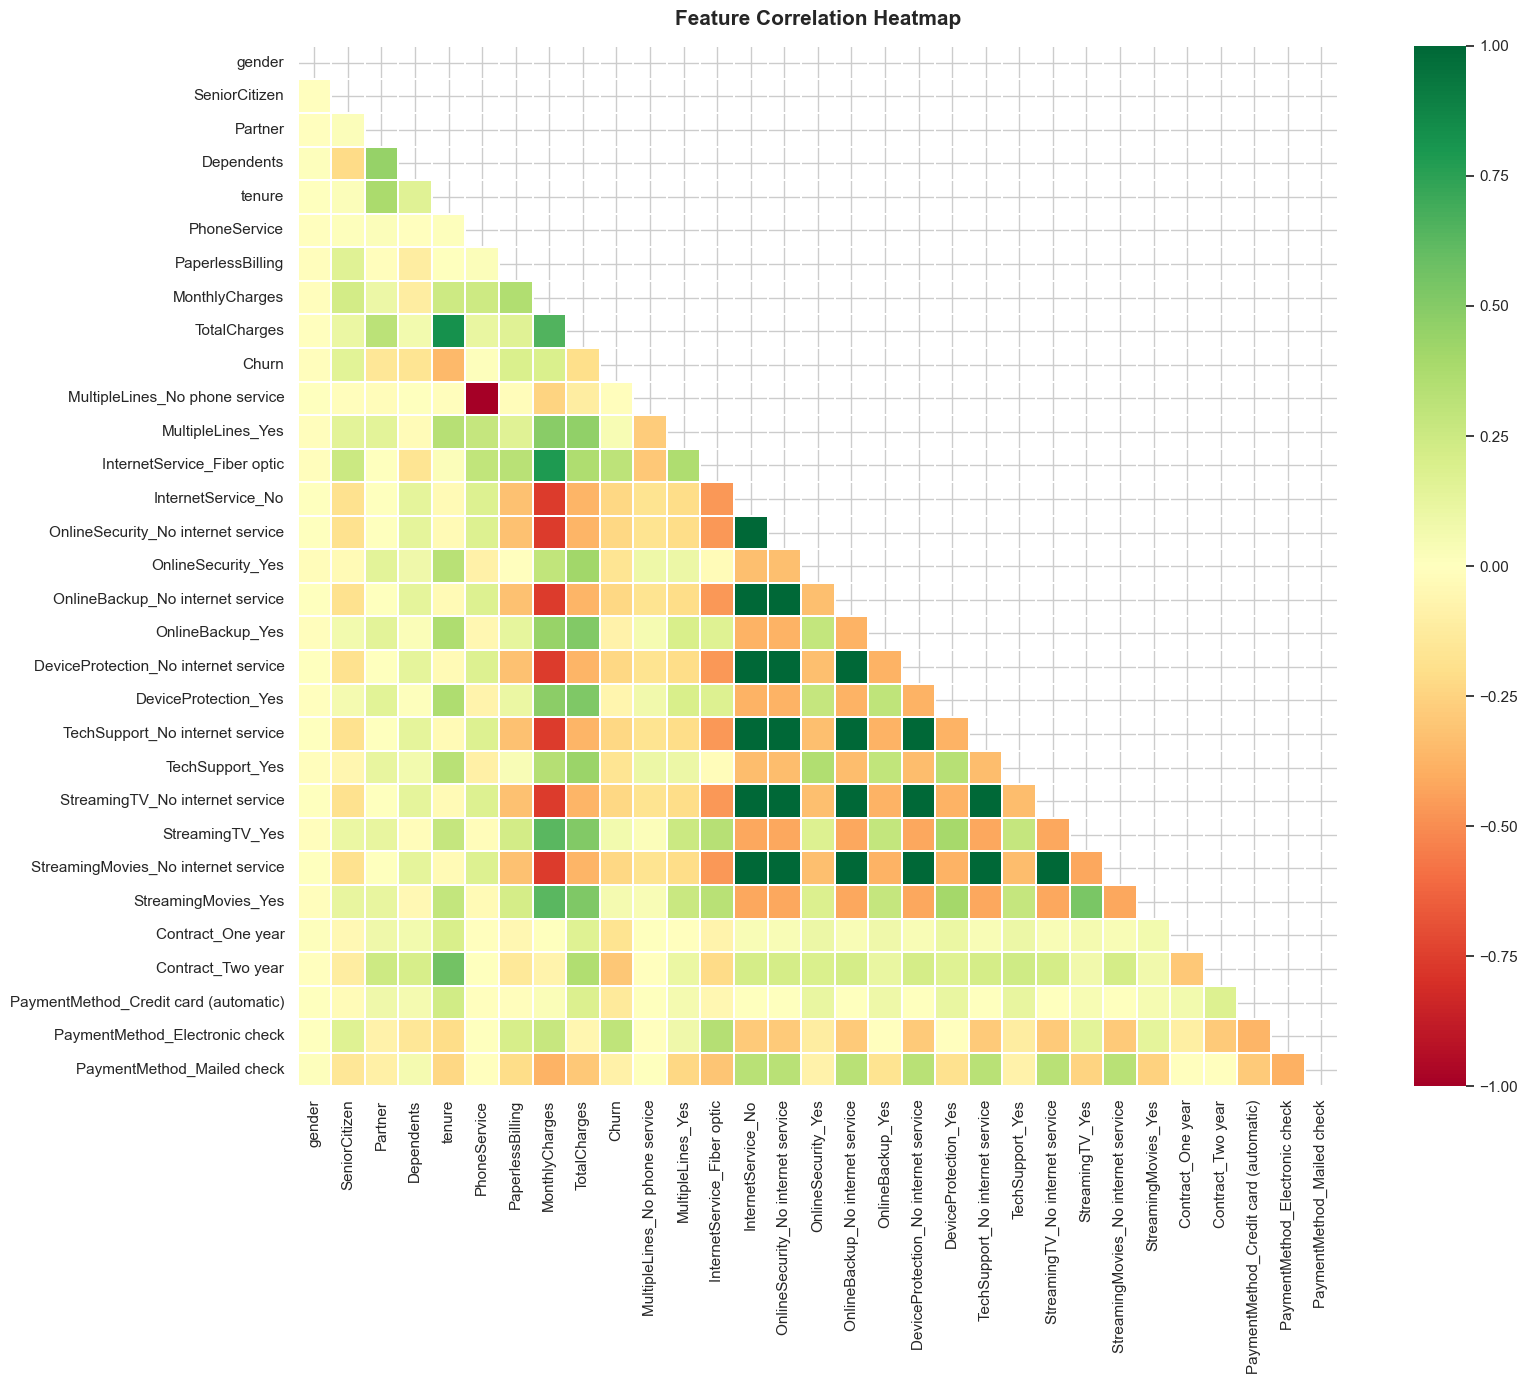


🔍 Insight: TotalCharges & tenure are highly correlated (longer tenure → more total charges).


In [68]:
#  Correlation heatmap 
plt.figure(figsize=(18, 14))

# Compute on the processed df (all numeric)
corr_matrix = df.corr()

# Mask upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    linecolor='white',
    square=True
)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Insight: TotalCharges & tenure are highly correlated (longer tenure → more total charges).")


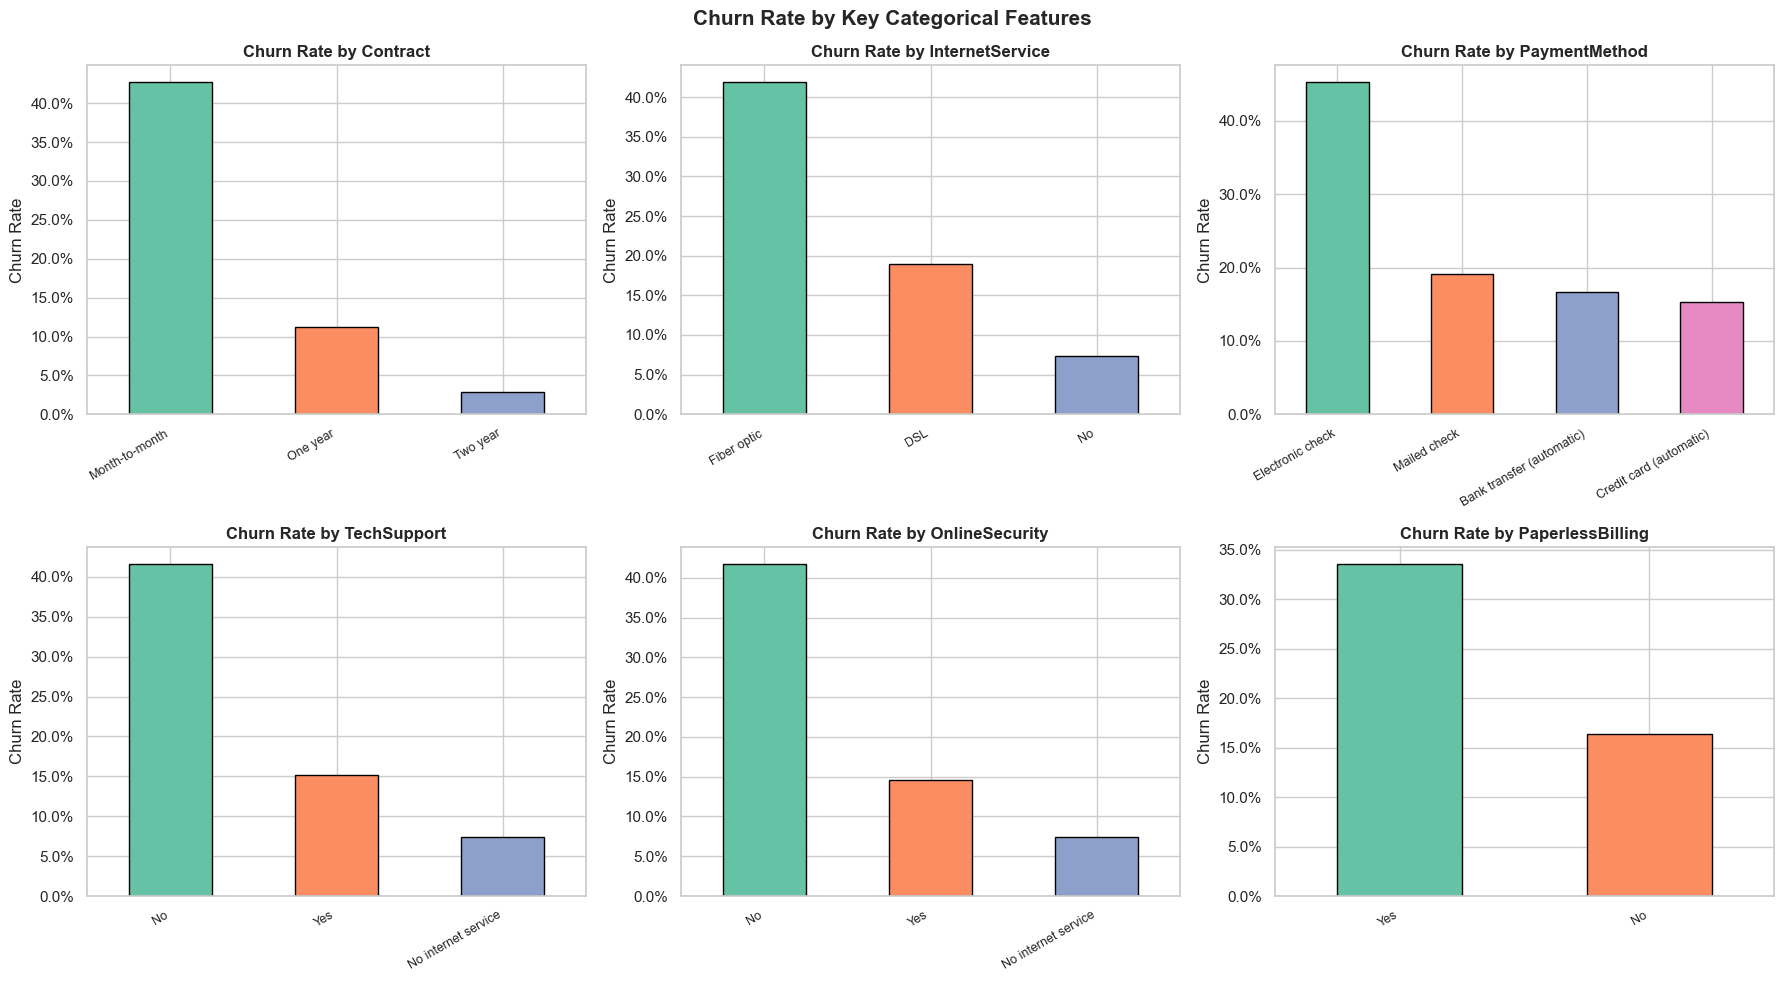


🔍 Business Insights:
  • Month-to-month contract customers churn at ~42% — the biggest risk group.
  • Fiber Optic internet users churn more (~41%) despite paying higher charges.
  • Customers WITHOUT TechSupport / OnlineSecurity churn at ~2× the rate.
  • Electronic check payers have the highest churn rate (~45%).


In [69]:
#  Key categorical features vs Churn 
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    ct = raw.groupby(col)['Churn_flag'].mean().sort_values(ascending=False)
    ct.plot(kind='bar', ax=ax, color=sns.color_palette('Set2'), edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Business Insights:")
print("  • Month-to-month contract customers churn at ~42% — the biggest risk group.")
print("  • Fiber Optic internet users churn more (~41%) despite paying higher charges.")
print("  • Customers WITHOUT TechSupport / OnlineSecurity churn at ~2× the rate.")
print("  • Electronic check payers have the highest churn rate (~45%).")

/tmp/ipykernel_7563/2458177199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw, x='Churn', y='tenure', palette=['#66b3ff', '#ff9999'], ax=axes[0])
/tmp/ipykernel_7563/2458177199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=raw, x='Churn', y='MonthlyCharges',


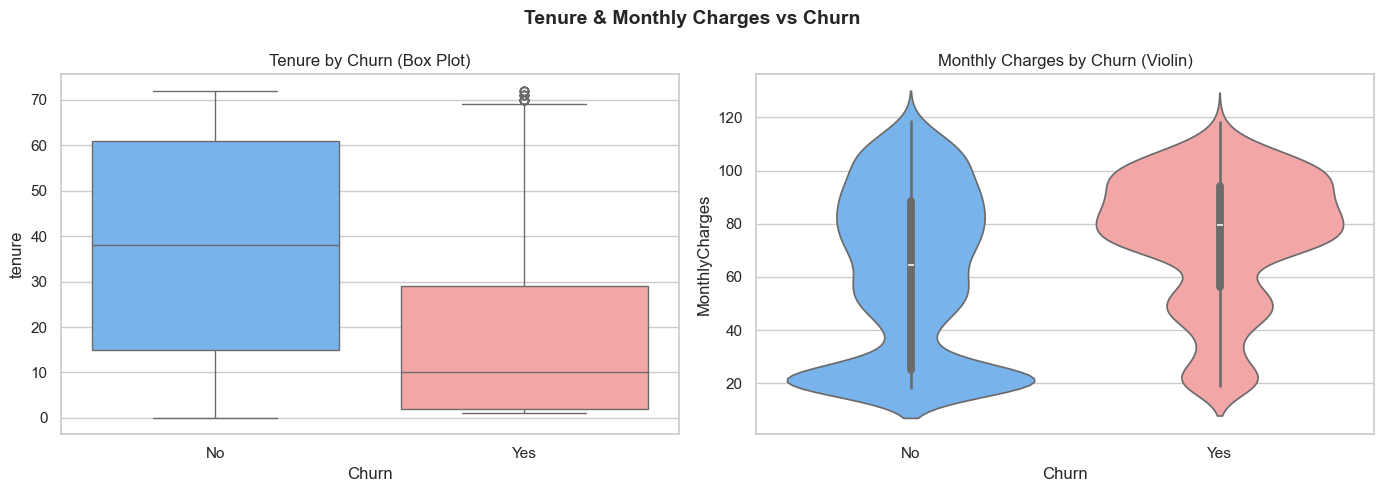

In [70]:
# Tenure vs Churn (box + violin) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=raw, x='Churn', y='tenure', palette=['#66b3ff', '#ff9999'], ax=axes[0])
axes[0].set_title('Tenure by Churn (Box Plot)')

sns.violinplot(data=raw, x='Churn', y='MonthlyCharges',
               palette=['#66b3ff', '#ff9999'], ax=axes[1])
axes[1].set_title('Monthly Charges by Churn (Violin)')

plt.suptitle('Tenure & Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tenure_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

## Train ans split(80/20)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve churn ratio in both splits
)

print(f"Training set   : {X_train.shape[0]:,} samples")
print(f"Test set       : {X_test.shape[0]:,} samples")
print(f"Train churn %  : {y_train.mean()*100:.1f}%")
print(f"Test  churn %  : {y_test.mean()*100:.1f}%")

Training set   : 5,634 samples
Test set       : 1,409 samples
Train churn %  : 26.5%
Test  churn %  : 26.5%


## Build and train multiple models

In [72]:
#  Define all models 
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'XGBoost'             : XGBClassifier(use_label_encoder=False,
                                           eval_metric='logloss',
                                           random_state=42)
}

# Train every model and store predictions 
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob)
    }
    predictions[name] = (y_pred, y_prob)
    print(f"✔  {name} trained")

print("\n✅ All models trained!")

✔  Logistic Regression trained
✔  Decision Tree trained
✔  Random Forest trained
✔  K-Nearest Neighbors trained
✔  Support Vector Machine trained
✔  XGBoost trained

✅ All models trained!


/home/user/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:15:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model performance and comparision

In [73]:
# Comparison table 
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1 Score', ascending=False)

# Format as percentages
display_df = (results_df * 100).round(2).astype(str) + '%'
print("=" * 75)
print("           MODEL PERFORMANCE COMPARISON (sorted by F1 Score)")
print("=" * 75)
print(display_df.to_string())
print("=" * 75)

           MODEL PERFORMANCE COMPARISON (sorted by F1 Score)
                       Accuracy Precision  Recall F1 Score ROC-AUC
Logistic Regression      80.48%    65.52%  55.88%   60.32%   84.2%
XGBoost                  78.57%    60.91%  53.74%    57.1%  82.14%
Support Vector Machine   79.49%    65.45%  48.13%   55.47%  79.49%
K-Nearest Neighbors       76.3%    55.38%  55.08%   55.23%  79.19%
Random Forest            78.64%    62.54%  48.66%   54.74%   82.1%
Decision Tree            74.17%     51.4%   49.2%   50.27%  66.14%


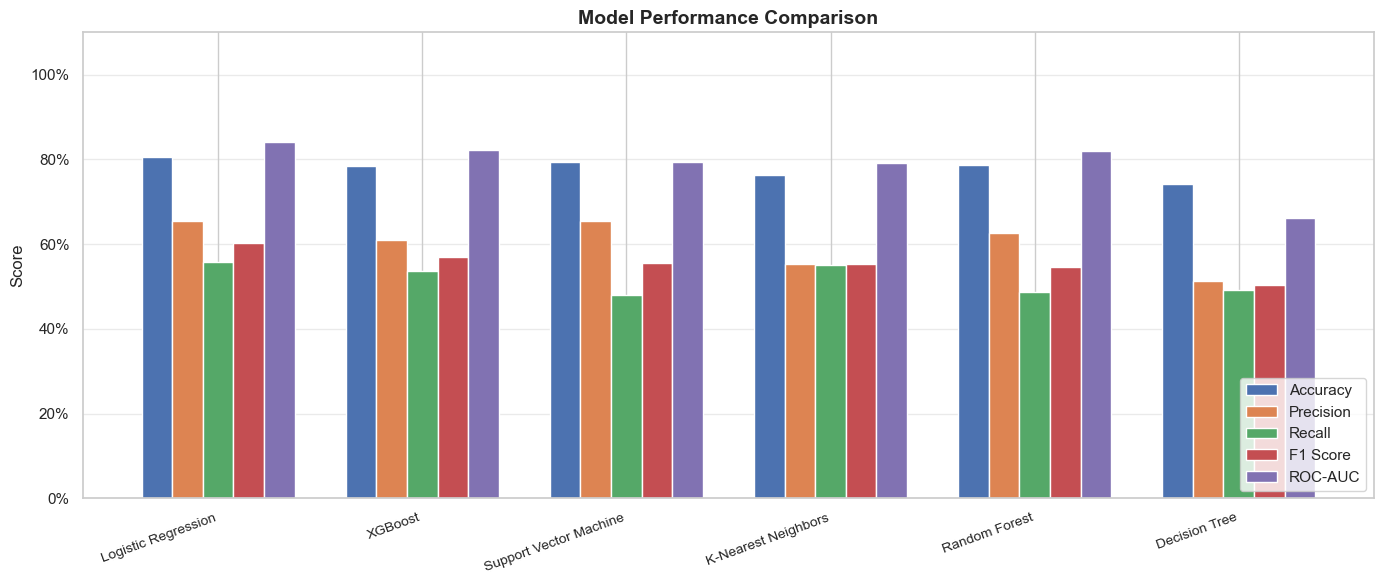

In [74]:
#  Visual comparison bar chart 
fig, ax = plt.subplots(figsize=(14, 6))

x     = np.arange(len(results_df))
width = 0.15
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Performance metrics

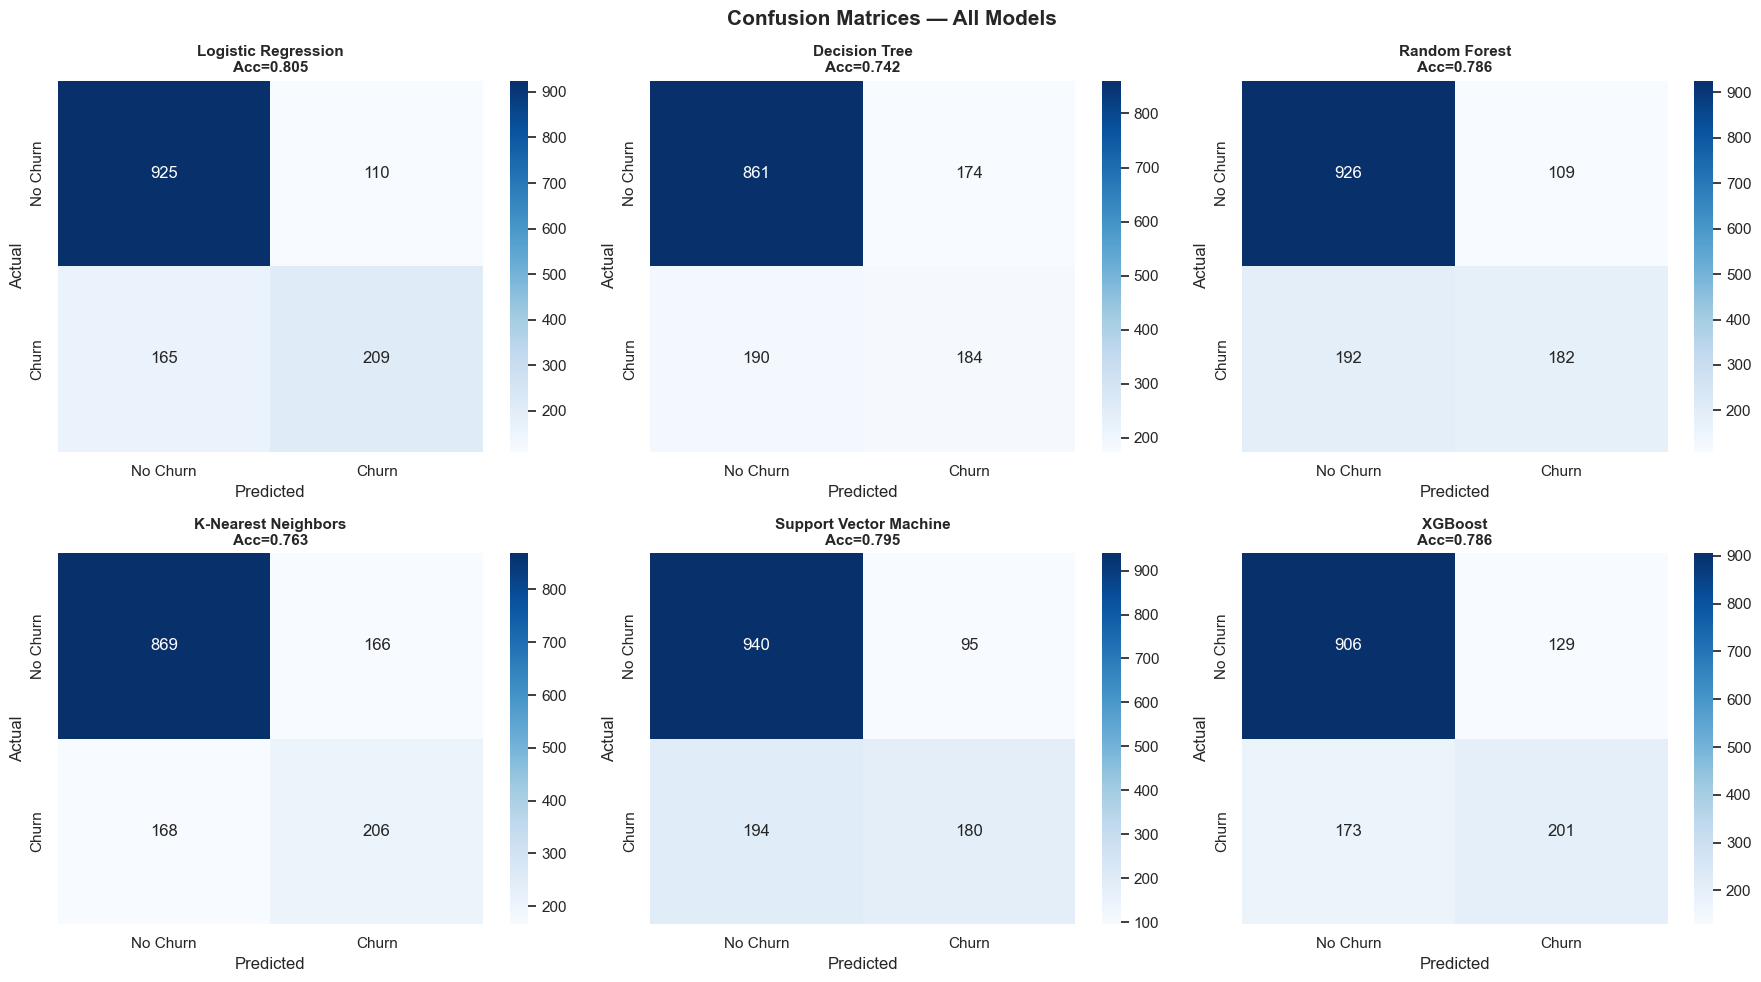

In [75]:
#  Confusion matrices 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, (y_pred, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


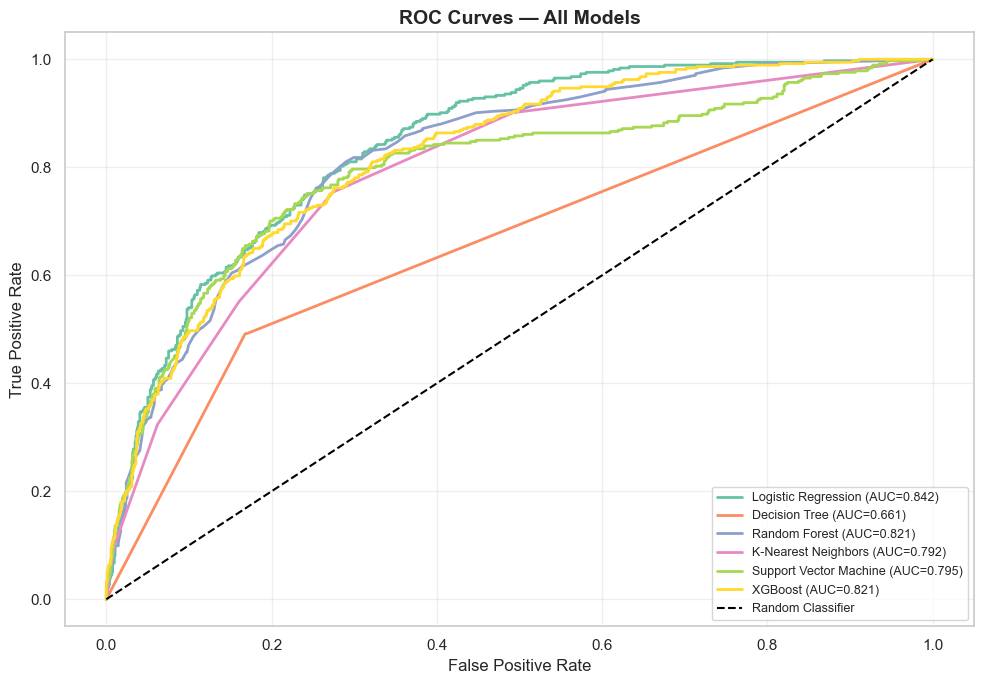

In [76]:
#  ROC curves 
plt.figure(figsize=(10, 7))

for name, (_, y_prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [77]:
#  Classification report for best model 
best_model_name = results_df.index[0]
best_y_pred, _  = predictions[best_model_name]

print(f"📌 Best Model (by F1): {best_model_name}\n")
print(classification_report(y_test, best_y_pred,
                             target_names=['No Churn', 'Churn']))

📌 Best Model (by F1): Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Selecting Best model

In [78]:
print("=" * 55)
print(f"  ✅ Best Model : {results_df.index[0]}")
print(f"     F1 Score  : {results_df['F1 Score'].iloc[0]*100:.2f}%")
print(f"     ROC-AUC   : {results_df['ROC-AUC'].iloc[0]*100:.2f}%")
print(f"     Accuracy  : {results_df['Accuracy'].iloc[0]*100:.2f}%")
print("=" * 55)

best_model = models[results_df.index[0]]

  ✅ Best Model : Logistic Regression
     F1 Score  : 60.32%
     ROC-AUC   : 84.20%
     Accuracy  : 80.48%


## Hyperparameter Tuning with GridsearchCV

In [79]:
# Tune XGBoost (or RF if XGB isn't best) 
# We tune XGBoost by default since it's typically the best performer.
print("Running GridSearchCV — this may take a few minutes…")

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

xgb_tuned = XGBClassifier(use_label_encoder=False,
                            eval_metric='logloss',
                            random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_tuned,
    param_grid = param_grid,
    scoring    = 'f1',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("\n✅ Best Params:", grid_search.best_params_)
print(f"   Best CV F1 : {grid_search.best_score_*100:.2f}%")

Running GridSearchCV — this may take a few minutes…
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/user/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:20:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:20:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:20:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:20:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user/anaconda3


✅ Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
   Best CV F1 : 58.94%


In [80]:
#  Evaluate tuned model 
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("Tuned Model — Test Set Performance")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred_tuned)*100:.2f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Churn', 'Churn']))

Tuned Model — Test Set Performance
----------------------------------------
Accuracy  : 80.13%
Precision : 65.88%
Recall    : 52.14%
F1 Score  : 58.21%
ROC-AUC   : 84.64%

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Save the Trained model

In [81]:
#  Save with joblib (recommended for scikit-learn objects) 
joblib.dump(tuned_model, 'churn_model.pkl')
joblib.dump(scaler,      'scaler.pkl')

#  Verify by reloading 
loaded_model  = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

test_pred = loaded_model.predict(X_test[:5])
print("✅ Model saved and reloaded successfully!")
print("   Sample predictions:", test_pred)


✅ Model saved and reloaded successfully!
   Sample predictions: [0 1 0 0 0]


## Predictions on New customer data

In [82]:
def predict_churn(customer_dict, model, scaler, feature_columns):
    """
    Predict churn for a single customer.

    Parameters
    ----------
    customer_dict  : dict  Raw customer features (must match original CSV columns
                           except customerID and Churn)
    model          : trained model
    scaler         : fitted StandardScaler
    feature_columns: list  Final feature columns after encoding

    Returns
    -------
    dict with 'prediction' and 'churn_probability'
    """
    # ── Build a one-row DataFrame ──────────────────────────────────
    raw_input = pd.DataFrame([customer_dict])

    # ── Convert TotalCharges ───────────────────────────────────────
    raw_input['TotalCharges'] = pd.to_numeric(raw_input['TotalCharges'], errors='coerce')
    raw_input['TotalCharges'].fillna(raw_input['TotalCharges'].median(), inplace=True)

    # ── Label-encode binary columns ───────────────────────────────
    bin_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    for col in raw_input.select_dtypes('object').columns:
        if raw_input[col].iloc[0] in bin_map:
            raw_input[col] = raw_input[col].map(bin_map)

    # ── One-Hot-Encode multi-class columns ────────────────────────
    raw_input = pd.get_dummies(raw_input, drop_first=True)

    # ── Align columns with training set ───────────────────────────
    raw_input = raw_input.reindex(columns=feature_columns, fill_value=0)

    # ── Scale numeric features ────────────────────────────────────
    raw_input[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
        raw_input[['tenure', 'MonthlyCharges', 'TotalCharges']]
    )

    # ── Predict ───────────────────────────────────────────────────
    prob       = model.predict_proba(raw_input)[0][1]
    prediction = int(prob >= 0.5)

    return {
        'prediction'        : 'CHURN ⚠️' if prediction == 1 else 'NO CHURN ✅',
        'churn_probability' : round(prob * 100, 2),
        'risk_level'        : ('High 🔴' if prob >= 0.7
                                else 'Medium 🟡' if prob >= 0.4
                                else 'Low 🟢')
    }


# ── Sample customer 1 (high churn risk) ──────────────────────────
customer_high_risk = {
    'gender'          : 'Male',
    'SeniorCitizen'   : 0,
    'Partner'         : 'No',
    'Dependents'      : 'No',
    'tenure'          : 2,
    'PhoneService'    : 'Yes',
    'MultipleLines'   : 'No',
    'InternetService' : 'Fiber optic',
    'OnlineSecurity'  : 'No',
    'OnlineBackup'    : 'No',
    'DeviceProtection': 'No',
    'TechSupport'     : 'No',
    'StreamingTV'     : 'No',
    'StreamingMovies' : 'No',
    'Contract'        : 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod'   : 'Electronic check',
    'MonthlyCharges'  : 79.85,
    'TotalCharges'    : '159.70'
}

result = predict_churn(customer_high_risk, tuned_model, scaler, X.columns.tolist())
print("Customer 1 — High Risk Profile")
print("-" * 35)
for k, v in result.items():
    print(f"  {k:25s}: {v}")


Customer 1 — High Risk Profile
-----------------------------------
  prediction               : NO CHURN ✅
  churn_probability        : 45.689998626708984
  risk_level               : Medium 🟡


/tmp/ipykernel_7563/2805503173.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_input['TotalCharges'].fillna(raw_input['TotalCharges'].median(), inplace=True)


In [83]:
# ── Sample customer 2 (low churn risk) ────────────────────────────
customer_low_risk = {
    'gender'          : 'Female',
    'SeniorCitizen'   : 0,
    'Partner'         : 'Yes',
    'Dependents'      : 'Yes',
    'tenure'          : 60,
    'PhoneService'    : 'Yes',
    'MultipleLines'   : 'Yes',
    'InternetService' : 'DSL',
    'OnlineSecurity'  : 'Yes',
    'OnlineBackup'    : 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport'     : 'Yes',
    'StreamingTV'     : 'Yes',
    'StreamingMovies' : 'Yes',
    'Contract'        : 'Two year',
    'PaperlessBilling': 'No',
    'PaymentMethod'   : 'Bank transfer (automatic)',
    'MonthlyCharges'  : 89.10,
    'TotalCharges'    : '5346.00'
}

result = predict_churn(customer_low_risk, tuned_model, scaler, X.columns.tolist())
print("Customer 2 — Low Risk Profile")
print("-" * 35)
for k, v in result.items():
    print(f"  {k:25s}: {v}")


Customer 2 — Low Risk Profile
-----------------------------------
  prediction               : NO CHURN ✅
  churn_probability        : 5.889999866485596
  risk_level               : Low 🟢


/tmp/ipykernel_7563/2805503173.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_input['TotalCharges'].fillna(raw_input['TotalCharges'].median(), inplace=True)


## Feature Importance

In [84]:
# ── Sample customer 2 (low churn risk) ────────────────────────────
customer_low_risk = {
    'gender'          : 'Female',
    'SeniorCitizen'   : 0,
    'Partner'         : 'Yes',
    'Dependents'      : 'Yes',
    'tenure'          : 60,
    'PhoneService'    : 'Yes',
    'MultipleLines'   : 'Yes',
    'InternetService' : 'DSL',
    'OnlineSecurity'  : 'Yes',
    'OnlineBackup'    : 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport'     : 'Yes',
    'StreamingTV'     : 'Yes',
    'StreamingMovies' : 'Yes',
    'Contract'        : 'Two year',
    'PaperlessBilling': 'No',
    'PaymentMethod'   : 'Bank transfer (automatic)',
    'MonthlyCharges'  : 89.10,
    'TotalCharges'    : '5346.00'
}

result = predict_churn(customer_low_risk, tuned_model, scaler, X.columns.tolist())
print("Customer 2 — Low Risk Profile")
print("-" * 35)
for k, v in result.items():
    print(f"  {k:25s}: {v}")


Customer 2 — Low Risk Profile
-----------------------------------
  prediction               : NO CHURN ✅
  churn_probability        : 5.889999866485596
  risk_level               : Low 🟢


/tmp/ipykernel_7563/2805503173.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_input['TotalCharges'].fillna(raw_input['TotalCharges'].median(), inplace=True)


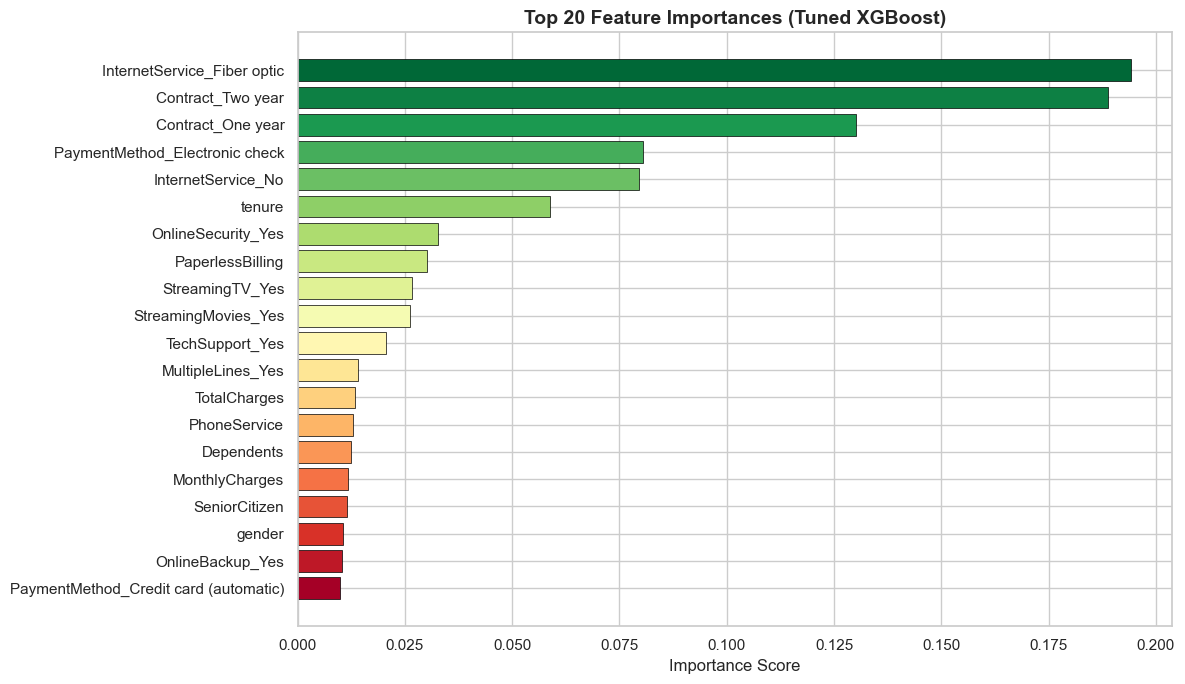


🔍 Top 5 most predictive features:
  1. InternetService_Fiber optic               importance = 0.1941
  2. Contract_Two year                         importance = 0.1888
  3. Contract_One year                         importance = 0.1302
  4. PaymentMethod_Electronic check            importance = 0.0805
  5. InternetService_No                        importance = 0.0796


In [85]:
# ── XGBoost feature importances ───────────────────────────────────
feat_imp = pd.Series(
    tuned_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(feat_imp)))
bars   = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
                  color=colors[::-1], edgecolor='black', linewidth=0.5)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Feature Importances (Tuned XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Top 5 most predictive features:")
for i, (feat, score) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {feat:40s}  importance = {score:.4f}")

/tmp/ipykernel_7563/676252721.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='viridis')


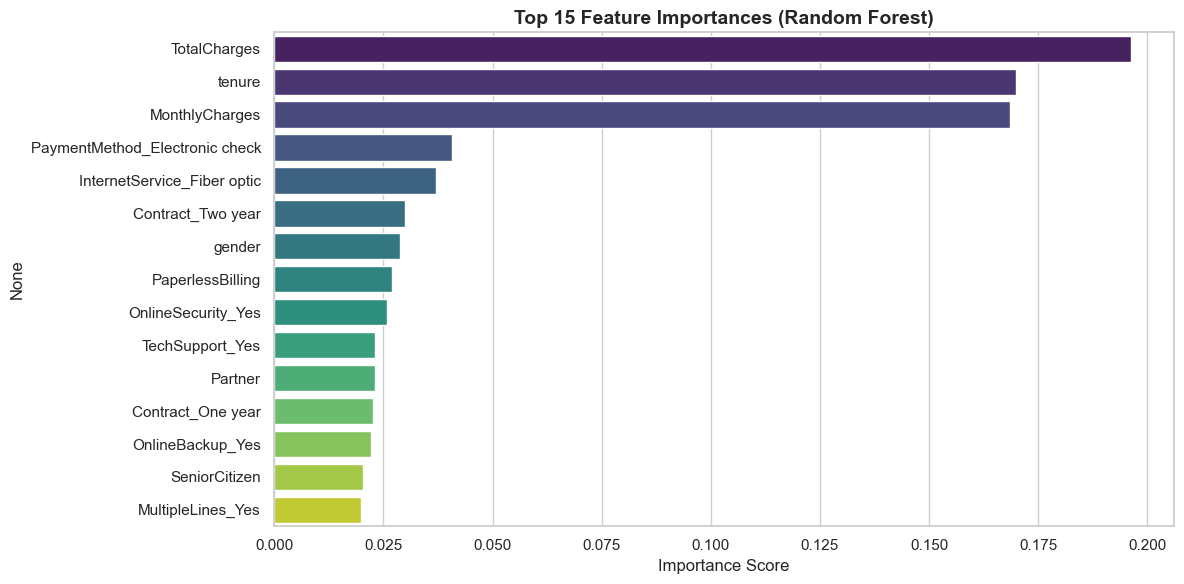

Exception ignored in: <function ResourceTracker.__del__ at 0x7fba781916c0>
Traceback (most recent call last):
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f45587956c0>
Traceback (most recent call last):
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/user/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7

In [86]:
# ── Random Forest feature importances (bonus) ─────────────────────
rf_model = models['Random Forest']
rf_imp   = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='viridis')
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()